In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv')

In [3]:
df.shape

(5000, 9)

In [4]:
df.columns

Index(['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score', 'converted'],
      dtype='object')

In [6]:
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [7]:
df.dtypes

lead_source                  object
industry                     object
employment_status            object
location                     object
annual_income               float64
number_of_courses_viewed      int64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

**Data preparation**

In [8]:
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [10]:
numerical = ['annual_income', 'lead_score']
categorical = ['lead_source', 'industry', 'employment_status', 'location']

In [11]:
df[categorical].nunique()

lead_source          5
industry             6
employment_status    4
location             5
dtype: int64

In [12]:
df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0.0)

In [13]:
df.isnull().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

**Question 1**

What is the most frequent observation (mode) for the column industry?

In [25]:
industry_mode = df['industry'].mode()
print("industry mode(s):", industry_mode.tolist())

industry mode(s): ['technology']


**Question 2**

What are the two features that have the biggest correlation?

In [26]:
pairs = [
    ('interaction_count', 'lead_score'),
    ('number_of_courses_viewed', 'lead_score'),
    ('number_of_courses_viewed', 'interaction_count'),
    ('annual_income', 'interaction_count'),
]

pair_corrs = {}
for a, b in pairs:
    if a in corr.index and b in corr.columns:
        pair_corrs[(a,b)] = corr.loc[a,b]
    else:
        pair_corrs[(a,b)] = np.nan

best_pair = max(pair_corrs.items(), key=lambda kv: abs(kv[1]) if not np.isnan(kv[1]) else -1)
print("biggest correlation among listed pairs:", best_pair[0])

biggest correlation among listed pairs: ('interaction_count', 'lead_score')


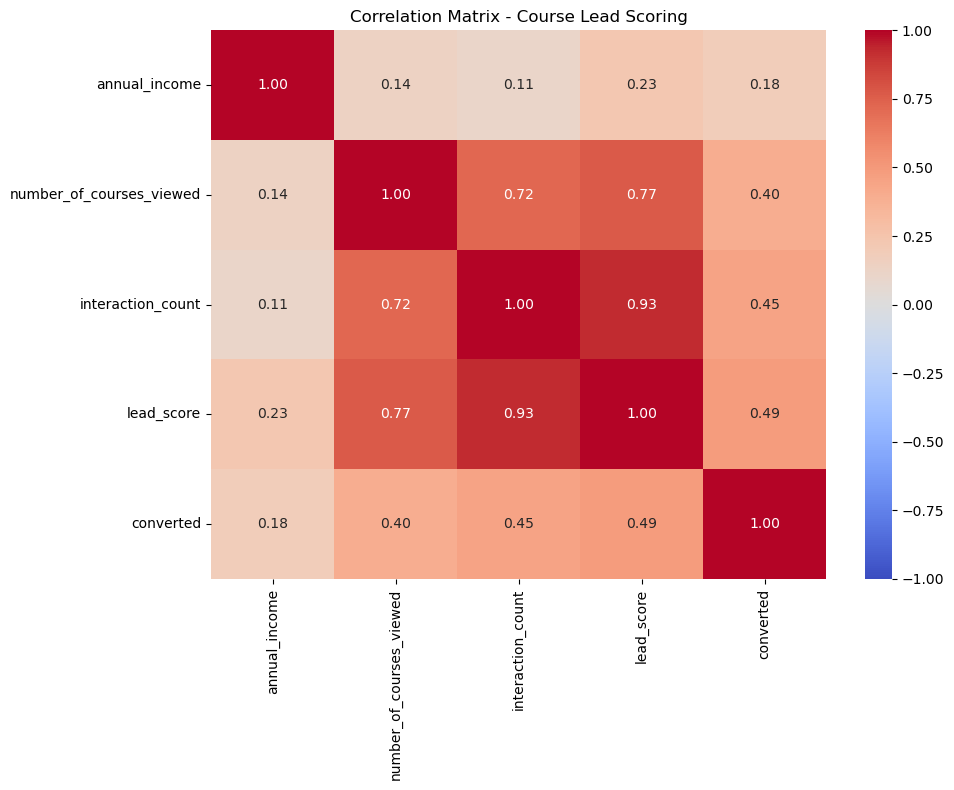

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_df = df.select_dtypes(include="number")
corr_matrix = numerical_df.corr()
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Correlation Matrix - Course Lead Scoring")
plt.tight_layout()
plt.show()


In [44]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df.converted)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42, stratify=df_full_train.converted)

len(df_train), len(df_val), len(df_test)

(3000, 1000, 1000)

**Split the data**

In [87]:
from sklearn.model_selection import train_test_split
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df.converted)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42, stratify=df_full_train.converted)

len(df_train), len(df_val), len(df_test)

(3000, 1000, 1000)

In [88]:
df_train

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
845,social_media,technology,employed,asia,81054.0,4,6,0.71,1
1962,referral,retail,employed,south_america,44626.0,3,6,0.67,1
4254,events,healthcare,employed,europe,68671.0,1,2,0.36,1
1421,organic_search,retail,self_employed,asia,41613.0,2,4,0.45,1
3020,organic_search,education,unemployed,north_america,27528.0,2,5,0.46,1
...,...,...,...,...,...,...,...,...,...
2091,referral,healthcare,employed,africa,58731.0,3,7,0.73,1
2121,NaN,technology,student,asia,NaN,2,6,0.48,1
894,events,healthcare,self_employed,north_america,66902.0,3,7,0.60,1
2739,paid_ads,retail,unemployed,europe,NaN,3,8,0.76,1


In [89]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [90]:
df_train

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,social_media,technology,employed,asia,81054.0,4,6,0.71,1
1,referral,retail,employed,south_america,44626.0,3,6,0.67,1
2,events,healthcare,employed,europe,68671.0,1,2,0.36,1
3,organic_search,retail,self_employed,asia,41613.0,2,4,0.45,1
4,organic_search,education,unemployed,north_america,27528.0,2,5,0.46,1
...,...,...,...,...,...,...,...,...,...
2995,referral,healthcare,employed,africa,58731.0,3,7,0.73,1
2996,NaN,technology,student,asia,NaN,2,6,0.48,1
2997,events,healthcare,self_employed,north_america,66902.0,3,7,0.60,1
2998,paid_ads,retail,unemployed,europe,NaN,3,8,0.76,1


In [91]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

**Question 3**

Which of these variables has the biggest mutual information score?

In [93]:
import pandas as pd
from sklearn.metrics import mutual_info_score

# Convert y_train to a Series with the same index as df_train
y_train_series = pd.Series(y_train, index=df_train.index)

def mutual_info_converted_score(series):
    score = mutual_info_score(
        series.fillna("missing"),
        y_train_series.fillna("missing")
    )
    return round(score, 2)

categorical = [
    "industry",
    "location",
    "lead_source",
    "employment_status"
]

mi = df_train[categorical].apply(mutual_info_converted_score)

print(mi.sort_values(ascending=False))
print("Highest score:", mi.idxmax())

lead_source          0.03
employment_status    0.02
industry             0.00
location             0.00
dtype: float64
Highest score: lead_source


**Question 4**

In [105]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

dv = DictVectorizer(sparse=False)

train_dict = df_train.to_dict(orient="records")
X_train = dv.fit_transform(train_dict)

val_dict = df_val.to_dict(orient="records")
X_val = dv.transform(val_dict)

model = LogisticRegression(
    solver="liblinear",
    C=1.0,
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)

print("Validation accuracy:", round(accuracy, 2))


Validation accuracy: 0.65


**Question 5**

Which of following feature has the smallest difference?

In [111]:
features_to_check = [
    "lead_source",
    "number_of_courses_viewed",
    "interaction_count"
]

def train_and_evaluate(features):
    dv = DictVectorizer(sparse=False)

    train_dict = df_train[features].to_dict(orient="records")
    val_dict = df_val[features].to_dict(orient="records")

    X_train = dv.fit_transform(train_dict)
    X_val = dv.transform(val_dict)

    model = LogisticRegression(
        solver="liblinear",
        C=1.0,
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    return accuracy_score(y_val, y_pred)

In [112]:
# Baseline accuracy with all features
all_features = df_train.columns.tolist()
original_accuracy = train_and_evaluate(all_features)

print("Original accuracy:", original_accuracy)

# Remove one feature at a time
for feature in features_to_check:
    remaining_features = [
        col for col in all_features if col != feature
    ]

    accuracy_without = train_and_evaluate(remaining_features)
    difference = original_accuracy - accuracy_without

    print(
        f"{feature}: "
        f"accuracy_without={accuracy_without:.6f}, "
        f"difference={difference:.6f}"
    )


Original accuracy: 0.645
lead_source: accuracy_without=0.642000, difference=0.003000
number_of_courses_viewed: accuracy_without=0.643000, difference=0.002000
interaction_count: accuracy_without=0.601000, difference=0.044000


**Question 6**

Which of these C leads to the best accuracy on the validation set?

In [113]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [118]:
C_values = [0.000001, 0.00001, 0.0001, 0.001]
accuracies = {}

for C in C_values:
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = (y_pred == y_val).mean()
    accuracies[C] = acc
    print(f"C={C:<5} -> Validation Accuracy: {acc:.3f}")

best_C = max(accuracies, key=accuracies.get)
print(f"\nBest C: {best_C} (Accuracy={accuracies[best_C]:.3f})")

C=1e-06 -> Validation Accuracy: 0.598
C=1e-05 -> Validation Accuracy: 0.598
C=0.0001 -> Validation Accuracy: 0.613
C=0.001 -> Validation Accuracy: 0.645

Best C: 0.001 (Accuracy=0.645)
